# KAMP PassOrFail Prediction — Hyperparameter-Tuned ML Pipeline (Random Reason-Balanced Split)

This notebook tunes **CatBoost, LightGBM, and XGBoost** with Optuna before the
local XAI and LLM-explanation stages.

Injection molding cycles are treated as independent samples, so time plays no
role in the experiment. The split and cross-validation are random (seeded)
rather than time-aware:

1. Startup-defect rows (`Reason == '초기허용불량'`) are removed from the dataset
   before splitting.
2. Hyperparameters are optimized only inside the training block.
3. Stratified K-fold cross-validation preserves the Pass/Fail ratio in every fold.
4. Mean validation PR-AUC is the optimization objective.
5. The classification threshold is selected from out-of-fold predictions using
   the F2-score, which gives more weight to failure recall.
6. The test set is evaluated only after tuning and threshold selection.
7. The model used by the later XAI stage is selected by cross-validation
   PR-AUC rather than by test-set performance.

All three estimators use the same preprocessing pipeline so that the selected
model remains compatible with the downstream SHAP/LIME functions in this
notebook.


## Main evaluation metrics

| Metric | Role in this experiment | Why it is used |
|---|---|---|
| PR-AUC | Primary hyperparameter and model-selection metric | Appropriate for a rare failure class and independent of the final threshold |
| Fail Recall | Main operational diagnostic | Measures how many actual failures are detected |
| Fail F1 | Balanced threshold-dependent diagnostic | Balances failure precision and recall |
| Fail F2 | Threshold-selection metric | Gives failure recall more weight than precision |

Overall accuracy is reported only as an auxiliary diagnostic because a model
that predicts every cycle as passing can still obtain very high accuracy in
this highly imbalanced dataset.

In [2]:
from pathlib import Path
import gc
import json
import os
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import optuna
import pandas as pd

from dotenv import load_dotenv
from IPython.display import IFrame, Markdown, display
from openai import OpenAI
from pyvis.network import Network

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Hyperparameter-tuned tabular classifiers.
# Install missing packages with:
# %pip install optuna xgboost lightgbm catboost
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Retained because later experimental cells may still import them.
from lingam import VARLiNGAM, DirectLiNGAM


RANDOM_STATE = 42
TARGET = "PassOrFail"

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

load_dotenv()
api_key = os.getenv("OPENROUTER_API_KEY")

## 1. Load the preprocessed dataset

In [3]:
DATA_PATH_CANDIDATES = [
    Path("labeled_data_preprocessed.csv"),
    Path("labeled_data_preprocessed(1).csv"),
    Path("../data/interim/labeled_data_preprocessed.csv"),
    Path("../data/processed/labeled_data_preprocessed.csv"),
    Path("/mnt/data/labeled_data_preprocessed.csv"),
    Path("/mnt/data/labeled_data_preprocessed(1).csv"),
]

DATA_PATH = next((p for p in DATA_PATH_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find labeled_data_preprocessed.csv. Update DATA_PATH_CANDIDATES.")

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH.resolve()}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print("Target distribution:")
print(df[TARGET].value_counts().rename(index={0: "Pass", 1: "Fail"}))
print("\nReason distribution among failures:")
print(df.loc[df[TARGET] == 1, "Reason"].value_counts(dropna=False))
df.head()


Loaded: C:\Users\Iman\OneDrive\Desktop\KAMO_injection_molding_analysis\data\interim\labeled_data_preprocessed.csv
Shape: 5,232 rows × 35 columns
Target distribution:
PassOrFail
Pass    5172
Fail      60
Name: count, dtype: int64

Reason distribution among failures:
Reason
가스        35
미성형       15
초기허용불량    10
Name: count, dtype: int64


,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,5f8928bb9c0189cc666ef19b,2020-10-16 04:57:47,2020-10-16 00:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,0,NaN,9.59,4.47,16.92,59.520000,7.13,653.409973,0.0,68.849998,647.98999,55.400002,30.700001,292.5,141.800003,136.800003,37.400002,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,0.0,66.300003,24.799999,27.5
1,5f8928de9c0189cc666ef20b,2020-10-16 04:58:48,2020-10-16 00:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,0,NaN,9.60,4.48,16.91,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,24.799999,27.6
2,5f8928df9c0189cc666ef213,2020-10-16 04:58:48,2020-10-16 00:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,0,NaN,9.60,4.48,16.91,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,24.799999,27.6
3,5f8928f39c0189cc666ef25e,2020-10-16 04:59:48,2020-10-16 00:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,0,NaN,9.59,4.48,16.91,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,25.000000,27.6
4,5f8928f59c0189cc666ef265,2020-10-16 04:59:48,2020-10-16 00:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,0,NaN,9.59,4.48,16.91,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,25.000000,27.6


In [4]:
df.shape

(5232, 35)

In [5]:
df["Reason"].value_counts()

Reason
가스        35
미성형       15
초기허용불량    10
Name: count, dtype: int64

In [6]:
import pandas as pd

# 1. Ensure the column is in datetime format
df["TimeStamp"] = pd.to_datetime(df["TimeStamp"])

# 2. Filter rows where the date matches "2020-10-27"
df[df["TimeStamp"].dt.date == pd.to_datetime("2020-10-27").date()]["Reason"]

2393    NaN
2394    NaN
2395    NaN
2396    NaN
2397    NaN
       ... 
3016    NaN
3017    NaN
3018    NaN
3019    NaN
3020    NaN
Name: Reason, Length: 628, dtype: str

In [7]:
# df["Reason"].value_counts()

df[df["Reason"]=="초기허용불량"]



# 2020-10-27 00:56:21

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
2461,5f9774fc9c0189cc668f6249,2020-10-27 00:56:21,2020-10-27 00:00:00,10,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,1,초기허용불량,13.39,8.27,16.650000,59.560001,7.12,653.630005,0.0,68.589996,647.98999,38.500000,30.799999,292.399994,147.399994,146.699997,38.099998,59.700001,275.799988,275.299988,275.299988,270.000000,255.699997,229.699997,0.0,64.400002,20.400000,21.700001
2462,5f9775049c0189cc668f62ae,2020-10-27 00:56:21,2020-10-27 00:00:00,9,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,1,초기허용불량,13.39,8.27,16.650000,59.560001,7.12,653.630005,0.0,68.589996,647.98999,38.500000,30.799999,292.399994,147.399994,146.699997,38.099998,59.700001,275.799988,275.299988,275.299988,270.000000,255.699997,229.699997,0.0,64.400002,20.400000,21.700001
2467,5f9775389c0189cc668f6644,2020-10-27 00:59:00,2020-10-27 00:00:00,9,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,1,초기허용불량,10.83,5.72,16.820000,62.360001,7.18,653.390015,0.0,68.580002,647.98999,45.400002,31.100000,292.399994,144.899994,142.699997,71.900002,87.099998,276.000000,274.799988,275.700012,268.899994,255.199997,229.800003,0.0,63.799999,20.600000,21.799999
2468,5f97753d9c0189cc668f6682,2020-10-27 00:59:00,2020-10-27 00:00:00,10,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,1,초기허용불량,10.83,5.72,16.820000,62.360001,7.18,653.390015,0.0,68.580002,647.98999,45.400002,31.100000,292.399994,144.899994,142.699997,71.900002,87.099998,276.000000,274.799988,275.700012,268.899994,255.199997,229.800003,0.0,63.799999,20.600000,21.799999
2469,5f9775459c0189cc668f66ea,2020-10-27 01:03:34,2020-10-27 00:00:00,9,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,1,초기허용불량,11.49,6.37,16.750000,62.360001,7.18,653.429993,0.0,68.589996,647.98999,45.099998,30.500000,292.500000,145.699997,144.199997,43.700001,62.900002,275.200012,275.500000,274.899994,272.100006,255.199997,230.100006,0.0,64.300003,20.500000,21.799999
2470,5f97754f9c0189cc668f67fc,2020-10-27 01:03:34,2020-10-27 00:00:00,10,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,1,초기허용불량,11.49,6.37,16.750000,62.360001,7.18,653.429993,0.0,68.589996,647.98999,45.099998,30.500000,292.500000,145.699997,144.199997,43.700001,62.900002,275.200012,275.500000,274.899994,272.100006,255.199997,230.100006,0.0,64.300003,20.500000,21.799999
2471,5f9775639c0189cc668f68fe,2020-10-27 01:04:41,2020-10-27 00:00:00,10,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,1,초기허용불량,9.98,4.87,16.530001,60.459999,7.12,653.409973,0.0,68.610001,647.98999,49.400002,30.700001,292.500000,142.899994,139.000000,50.599998,67.400002,276.000000,275.299988,275.100006,271.600006,255.199997,229.600006,0.0,65.000000,20.700001,22.000000
2472,5f97756d9c0189cc668f6a00,2020-10-27 01:04:41,2020-10-27 00:00:00,9,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,1,초기허용불량,9.98,4.87,16.530001,60.459999,7.12,653.409973,0.0,68.610001,647.98999,49.400002,30.700001,292.500000,142.899994,139.000000,50.599998,67.400002,276.000000,275.299988,275.100006,271.600006,255.199997,229.600006,0.0,65.000000,20.700001,22.000000
2473,5f9775729c0189cc668f6a4c,2020-10-27 01:05:41,2020-10-27 00:00:00,10,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,1,초기허용불량,9.70,4.58,16.469999,58.959999,7.12,653.450012,0.0,68.589996,647.98999,53.299999,30.500000,292.299988,142.199997,137.399994,38.599998,60.200001,276.799988,275.100006,275.700012,270.899994,255.399994,229.399994,0.0,64.500000,20.600000,21.900000
2474,5f97757a9c0189cc668f6aaa,2020-10-27 01:05:41,2020-10-27 00:00:00,9,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,1,초기허용불량,9.70,4.58,16.469999,58.9

## 2. Random reason-balanced 80/20 train/test split

Injection molding cycles are treated as independent samples, so time plays no
role in the split. The split is random (seeded with `RANDOM_STATE`) and built
so the test set is balanced across the two failure reasons of interest:

1. Rows with `Reason == '초기허용불량'` (startup defects) are **removed from the
   dataset entirely** — they are an expected part of process stabilization and
   not a meaningful target for root-cause explanation.
2. For each remaining failure reason (`가스`, `미성형`), exactly
   `N_TEST_PER_REASON` (= 5) failures are drawn at random into the test set,
   so the test failures are balanced between the two reasons.
3. All remaining failures stay in the training set so the models can actually
   learn both failure modes — a prerequisite for obtaining true-positive
   predictions on the test set.
4. Passed cycles are split randomly: ~80% train / ~20% test.


In [8]:
if "Reason" not in df.columns:
    raise ValueError("The dataset must contain Reason for the explanation-evaluation study.")

# ------------------------------------------------------------------
# Random reason-balanced 80/20 split (no time-awareness)
# ------------------------------------------------------------------
EXCLUDED_REASONS = ["초기허용불량"]
BALANCED_TEST_REASONS = ["가스", "미성형"]
N_TEST_PER_REASON = 5
TEST_FRACTION = 0.20

rng = np.random.RandomState(RANDOM_STATE)

# 1. Remove startup-defect rows entirely: they are never trained on,
#    tested on, or explained.
model_df = df.loc[~df["Reason"].isin(EXCLUDED_REASONS)].reset_index(drop=True)
print(f"Removed {len(df) - len(model_df)} rows with Reason in {EXCLUDED_REASONS}.")

# 2. Draw the same number of failures per required reason into the test set
#    so the test failures are balanced across the reasons of interest.
test_index = []
for reason in BALANCED_TEST_REASONS:
    reason_idx = model_df.index[(model_df[TARGET] == 1) & (model_df["Reason"] == reason)].to_numpy()
    if len(reason_idx) <= N_TEST_PER_REASON:
        raise ValueError(
            f"Need more than {N_TEST_PER_REASON} failures with Reason == '{reason}' "
            f"so that some remain for training, found {len(reason_idx)}."
        )
    test_index.extend(rng.choice(reason_idx, size=N_TEST_PER_REASON, replace=False).tolist())

# 3. Split the passed cycles randomly ~80/20.
pass_idx = model_df.index[model_df[TARGET] == 0].to_numpy()
n_test_pass = int(round(len(pass_idx) * TEST_FRACTION))
test_index.extend(rng.choice(pass_idx, size=n_test_pass, replace=False).tolist())

test_index = pd.Index(sorted(test_index))

# 4. Everything else (including all remaining failures) is training data.
#    Shuffle the training rows so no residual ordering remains.
train_df = model_df.drop(index=test_index).sample(frac=1.0, random_state=RANDOM_STATE)
test_df = model_df.loc[test_index]

# Keep val_df/y_val as empty objects only for compatibility with later cells.
# The experiment uses only train/test.
val_df = model_df.iloc[0:0]

split_summary = pd.DataFrame({
    "split": ["train", "validation_removed", "test"],
    "rows": [len(train_df), len(val_df), len(test_df)],
    "failures": [int(train_df[TARGET].sum()), int(val_df[TARGET].sum()), int(test_df[TARGET].sum())],
})

print("\nSplit summary:")
display(split_summary)

print(f"\nTrain rows: {len(train_df)} ({len(train_df) / len(model_df):.1%}), "
      f"Test rows: {len(test_df)} ({len(test_df) / len(model_df):.1%})")

print("\nFailure reasons in train:")
display(train_df.loc[train_df[TARGET] == 1, "Reason"].value_counts(dropna=False).to_frame("count"))

print("\nFailure reasons in test:")
display(test_df.loc[test_df[TARGET] == 1, "Reason"].value_counts(dropna=False).to_frame("count"))

# Confirm the test failures are balanced across the required reasons.
for reason in BALANCED_TEST_REASONS:
    reason_count = int(((test_df[TARGET] == 1) & (test_df["Reason"] == reason)).sum())
    if reason_count != N_TEST_PER_REASON:
        raise ValueError(
            f"Expected exactly {N_TEST_PER_REASON} test failures with Reason == '{reason}', found {reason_count}."
        )
    print(f"Confirmed: test_df contains {reason_count} failures with Reason == '{reason}'.")

if int(test_df[TARGET].sum()) != N_TEST_PER_REASON * len(BALANCED_TEST_REASONS):
    raise ValueError("The test set contains unexpected extra failures.")


Removed 10 rows with Reason in ['초기허용불량'].

Split summary:


,split,rows,failures
0,train,4178,40
1,validation_removed,0,0
2,test,1044,10



Train rows: 4178 (80.0%), Test rows: 1044 (20.0%)

Failure reasons in train:


,count
Reason,
가스,30
미성형,10



Failure reasons in test:


,count
Reason,
미성형,5
가스,5


Confirmed: test_df contains 5 failures with Reason == '가스'.
Confirmed: test_df contains 5 failures with Reason == '미성형'.


In [9]:
4174+1058

5232

In [10]:
df["PassOrFail"].value_counts()

PassOrFail
0    5172
1      60
Name: count, dtype: int64

## 3. Feature preparation

`Reason` is removed because it directly reveals why a product failed and is missing for all passed products. `TimeStamp` is dropped as well: time plays no role in this experiment, neither for splitting nor as a predictor. Serial/id-like columns are removed to reduce leakage and overfitting risk.


In [11]:
LEAKAGE_OR_ID_COLUMNS = [
    TARGET,
    "Reason",                 # direct label leakage; kept in test_df only for explanation evaluation metadata
    "_id",                    # row identifier
    "TimeStamp",              # not a predictor; time plays no role in this experiment
    "PART_FACT_PLAN_DATE",    # raw date; avoid date memorization
    "PART_FACT_SERIAL",       # serial/order identifier; avoid memorization
]

def make_xy(data: pd.DataFrame):
    y = data[TARGET].astype(int)
    drop_cols = [c for c in LEAKAGE_OR_ID_COLUMNS if c in data.columns]
    X = data.drop(columns=drop_cols)
    return X, y

X_train, y_train = make_xy(train_df)
X_val, y_val = make_xy(val_df)   # empty; kept only for compatibility with later cells
X_test, y_test = make_xy(test_df)

print("X_train:", X_train.shape, "failures:", int(y_train.sum()))
print("X_val:  ", X_val.shape, "failures:", int(y_val.sum()), "[validation removed]")
print("X_test: ", X_test.shape, "failures:", int(y_test.sum()))

print("\nX_test failure reason distribution:")
display(test_df.loc[test_df[TARGET] == 1, "Reason"].value_counts(dropna=False).to_frame("count"))

X_train.head()


X_train: (4178, 29) failures: 40
X_val:   (0, 29) failures: 0 [validation removed]
X_test:  (1044, 29) failures: 10

X_test failure reason distribution:


,count
Reason,
미성형,5
가스,5


,PART_NAME,EQUIP_CD,EQUIP_NAME,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
1849,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,1.06,0.94,12.890000,61.759998,6.81,654.260010,0.0,53.570000,4.63000,128.300003,30.799999,290.500000,142.500000,116.199997,55.700001,60.500000,285.500000,285.600006,285.100006,274.600006,265.200012,234.600006,0.0,66.000000,23.000000,24.000000
2598,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,9.61,4.50,16.889999,59.580002,7.12,653.440002,0.0,68.580002,647.98999,55.299999,30.600000,292.500000,142.100006,137.100006,38.200001,59.700001,276.100006,275.500000,274.899994,270.799988,255.000000,230.300003,0.0,68.599998,23.299999,24.500000
831,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,9.54,4.43,17.080000,59.480000,7.12,653.409973,0.0,68.480003,647.98999,56.200001,30.700001,292.600006,141.699997,136.399994,38.400002,59.599998,276.799988,275.700012,275.299988,269.899994,255.199997,229.699997,0.0,68.000000,23.100000,24.200001
2818,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,9.58,4.47,16.840000,59.560001,7.12,653.460022,0.0,68.580002,647.98999,55.599998,30.700001,292.399994,141.899994,136.500000,37.599998,59.400002,276.000000,275.299988,274.899994,270.799988,254.899994,230.100006,0.0,65.800003,22.500000,23.799999
1302,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,1.06,0.93,12.990000,61.779999,6.80,654.260010,0.0,53.590000,4.63000,128.300003,30.700001,290.600006,142.600006,116.300003,55.700001,60.400002,286.600006,284.899994,285.500000,275.000000,264.200012,235.100006,0.0,66.199997,22.000000,23.100000


In [12]:
X_test

,PART_NAME,EQUIP_CD,EQUIP_NAME,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
8,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,9.58,4.46,16.92,59.560001,7.13,653.409973,0.0,68.849998,647.98999,55.500000,30.600000,292.399994,141.800003,136.699997,37.400002,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,0.0,67.000000,25.000000,27.600000
12,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,9.56,4.45,16.90,59.520000,7.14,653.409973,0.0,68.839996,647.98999,55.700001,30.700001,292.500000,141.600006,136.300003,36.900002,59.000000,276.200012,275.200012,274.500000,270.299988,255.000000,230.100006,0.0,67.000000,25.000000,27.600000
17,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,9.58,4.47,16.92,59.520000,7.13,653.409973,0.0,68.839996,647.98999,55.500000,30.700001,292.399994,141.699997,136.800003,37.099998,59.099998,276.399994,275.000000,275.799988,269.100006,254.399994,229.800003,0.0,67.800003,24.700001,27.600000
23,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,9.59,4.47,16.91,59.560001,7.13,653.409973,0.0,68.860001,647.98999,55.400002,30.600000,292.500000,141.800003,136.800003,37.700001,59.400002,276.100006,274.799988,274.500000,271.600006,254.500000,229.600006,0.0,67.099998,24.900000,27.500000
26,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,9.59,4.47,16.90,59.580002,7.13,653.409973,0.0,68.830002,647.98999,55.400002,30.600000,292.500000,141.699997,136.800003,37.500000,59.299999,276.200012,275.000000,275.399994,271.799988,255.000000,230.100006,0.0,67.500000,24.900000,27.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5188,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,1.07,0.95,13.15,61.740002,6.79,654.219971,0.0,53.619999,4.63000,127.099998,30.900000,29.000000,143.399994,118.900002,57.700001,62.000000,286.000000,284.899994,284.799988,274.399994,265.799988,234.500000,0.0,63.400002,22.400000,24.200001
5199,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,1.07,0.94,13.13,61.740002,6.79,654.239990,0.0,53.610001,4.63000,127.400002,31.000000,29.000000,143.100006,118.599998,57.500000,61.900002,286.000000,285.200012,285.600006,274.600006,264.899994,234.800003,0.0,64.000000,22.400000,24.400000
5202,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,1.07,0.95,13.14,61.779999,6.79,654.229980,0.0,53.619999,4.63000,127.300003,31.000000,29.000000,143.199997,118.599998,57.500000,61.900002,285.299988,284.799988,284.700012,274.600006,265.100006,234.699997,0.0,63.099998,22.500000,24.400000
5218,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,1.07,0.94,13.12,61.779999,6.79,654.250000,0.0,53.610001,4.63000,127.500000,31.100000,29.000000,143.000000,118.300003,57.099998,61.500000,285.899994,284.899994,285.700012,274.899994,265.000000,234.899994,0.0,64.500000,22.500000,24.299999


In [13]:
# Candidate failure rows for explanation evaluation.
# These are the rows available in X_test/y_test, with Reason kept in test_df metadata.

test_failure_candidates = (
    test_df.loc[test_df[TARGET] == 1, ["TimeStamp", TARGET, "Reason"]]
    .copy()
)

display(test_failure_candidates)

print("Rows by Reason in test failures:")
display(test_failure_candidates.groupby("Reason").size().to_frame("count"))

# 가스 => Gas
# 미성형 => Short shot / incomplete molding


,TimeStamp,PassOrFail,Reason
115,2020-10-16 05:55:21,1,미성형
116,2020-10-16 05:55:21,1,미성형
1347,2020-10-22 00:51:52,1,가스
1415,2020-10-22 01:26:54,1,가스
1515,2020-10-22 04:48:39,1,미성형
1621,2020-10-22 05:44:15,1,가스
1937,2020-10-23 01:24:09,1,가스
2021,2020-10-23 02:25:54,1,미성형
2105,2020-10-23 05:15:46,1,가스
2163,2020-10-23 05:47:40,1,미성형


Rows by Reason in test failures:


,count
Reason,
가스,5
미성형,5


## 4. Preprocessing pipeline

The tree-based models do not require scaling. Numeric columns are median-imputed; categorical columns are imputed and one-hot encoded.


In [14]:
def make_one_hot_encoder():
    # Compatibility with older and newer scikit-learn versions.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(X_frame: pd.DataFrame) -> ColumnTransformer:
    numeric_features = X_frame.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X_frame.select_dtypes(exclude=np.number).columns.tolist()

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )


## 5. Tune CatBoost, LightGBM, and XGBoost

All three models are tuned independently with Optuna. Each Optuna trial is
evaluated with stratified K-fold cross-validation on the training block, and
**mean validation PR-AUC** is maximized.

The default is 60 trials per model. Reduce this value while testing the
notebook or increase it for the final experiment if computational resources
allow.


In [15]:
# ------------------------------------------------------------------
# Tuning configuration
# ------------------------------------------------------------------
N_TRIALS_PER_MODEL = {
    "CatBoost": 60,
    "LightGBM": 60,
    "XGBoost": 60,
}

N_CV_SPLITS = 4
THRESHOLD_BETA = 2.0

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
base_scale_pos_weight = negative_count / max(positive_count, 1)

# Tune around the empirical imbalance ratio instead of fixing it.
minimum_positive_weight = max(1.0, base_scale_pos_weight * 0.15)
maximum_positive_weight = max(
    minimum_positive_weight * 1.1,
    base_scale_pos_weight * 2.5,
)

print("Training rows:", len(y_train))
print("Negative examples:", negative_count)
print("Positive examples:", positive_count)
print("Base scale_pos_weight:", round(base_scale_pos_weight, 2))
print(
    "Tuned scale_pos_weight range:",
    f"{minimum_positive_weight:.2f} to {maximum_positive_weight:.2f}",
)

# Stratified K-fold keeps the Pass/Fail ratio similar in every fold, which is
# appropriate because the molding cycles are treated as independent samples.
cv = StratifiedKFold(
    n_splits=N_CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
valid_cv_splits = []

for fold_number, (train_indices, validation_indices) in enumerate(
    cv.split(X_train, y_train),
    start=1,
):
    y_fold_train = y_train.iloc[train_indices]
    y_fold_validation = y_train.iloc[validation_indices]

    train_failures = int(y_fold_train.sum())
    validation_failures = int(y_fold_validation.sum())

    print(
        f"Fold {fold_number}: "
        f"train rows={len(train_indices):,}, train failures={train_failures}; "
        f"validation rows={len(validation_indices):,}, "
        f"validation failures={validation_failures}"
    )

    # PR-AUC cannot be meaningfully calculated if a validation block has no
    # failure examples. A training block also needs both classes.
    if y_fold_train.nunique() < 2:
        print("  Skipped: training fold contains only one class.")
        continue

    if validation_failures == 0:
        print("  Skipped: validation fold contains no failures.")
        continue

    valid_cv_splits.append((train_indices, validation_indices))

if len(valid_cv_splits) < 2:
    raise ValueError(
        "Fewer than two usable validation folds contain failures. "
        "Reduce N_CV_SPLITS or define custom folds."
    )

print("\nUsable folds:", len(valid_cv_splits))


Training rows: 4178
Negative examples: 4138
Positive examples: 40
Base scale_pos_weight: 103.45
Tuned scale_pos_weight range: 15.52 to 258.62
Fold 1: train rows=3,133, train failures=30; validation rows=1,045, validation failures=10
Fold 2: train rows=3,133, train failures=30; validation rows=1,045, validation failures=10
Fold 3: train rows=3,134, train failures=30; validation rows=1,044, validation failures=10
Fold 4: train rows=3,134, train failures=30; validation rows=1,044, validation failures=10

Usable folds: 4


## 6. Hyperparameter search spaces and evaluation helpers

The estimators share the existing one-hot preprocessing pipeline. This keeps
the final fitted object compatible with the downstream local SHAP/LIME
functions, which expect a scikit-learn `Pipeline` with `preprocess` and
`model` steps.

In [16]:
def get_failure_scores(pipeline: Pipeline, X: pd.DataFrame) -> np.ndarray:
    """Return the predicted probability/score for the Fail class."""
    X_transformed = pipeline.named_steps["preprocess"].transform(X)
    model = pipeline.named_steps["model"]

    if hasattr(model, "predict_proba"):
        return np.asarray(model.predict_proba(X_transformed))[:, 1]

    return np.asarray(model.decision_function(X_transformed))


def sample_model_parameters(
    trial: optuna.Trial,
    model_name: str,
) -> dict:
    """Draw one model-specific hyperparameter configuration."""

    if model_name == "CatBoost":
        return {
            "iterations": trial.suggest_int(
                "iterations", 300, 1800, step=100
            ),
            "depth": trial.suggest_int("depth", 3, 9),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.005, 0.15, log=True
            ),
            "l2_leaf_reg": trial.suggest_float(
                "l2_leaf_reg", 1e-3, 30.0, log=True
            ),
            "random_strength": trial.suggest_float(
                "random_strength", 1e-3, 10.0, log=True
            ),
            "bagging_temperature": trial.suggest_float(
                "bagging_temperature", 0.0, 5.0
            ),
            "border_count": trial.suggest_categorical(
                "border_count", [32, 64, 128, 254]
            ),
            "scale_pos_weight": trial.suggest_float(
                "scale_pos_weight",
                minimum_positive_weight,
                maximum_positive_weight,
                log=True,
            ),
        }

    if model_name == "LightGBM":
        return {
            "n_estimators": trial.suggest_int(
                "n_estimators", 200, 1800, step=100
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.005, 0.15, log=True
            ),
            "num_leaves": trial.suggest_int("num_leaves", 3, 63),
            "max_depth": trial.suggest_int("max_depth", 2, 10),
            "min_child_samples": trial.suggest_int(
                "min_child_samples", 5, 200
            ),
            "subsample": trial.suggest_float("subsample", 0.60, 1.00),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.50, 1.00
            ),
            "reg_alpha": trial.suggest_float(
                "reg_alpha", 1e-8, 10.0, log=True
            ),
            "reg_lambda": trial.suggest_float(
                "reg_lambda", 1e-8, 30.0, log=True
            ),
            "min_split_gain": trial.suggest_float(
                "min_split_gain", 0.0, 1.0
            ),
            "max_bin": trial.suggest_categorical(
                "max_bin", [31, 63, 127, 255]
            ),
            "scale_pos_weight": trial.suggest_float(
                "scale_pos_weight",
                minimum_positive_weight,
                maximum_positive_weight,
                log=True,
            ),
        }

    if model_name == "XGBoost":
        return {
            "n_estimators": trial.suggest_int(
                "n_estimators", 200, 1800, step=100
            ),
            "max_depth": trial.suggest_int("max_depth", 2, 9),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.005, 0.15, log=True
            ),
            "min_child_weight": trial.suggest_float(
                "min_child_weight", 1e-2, 30.0, log=True
            ),
            "subsample": trial.suggest_float("subsample", 0.60, 1.00),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.50, 1.00
            ),
            "gamma": trial.suggest_float(
                "gamma", 1e-8, 10.0, log=True
            ),
            "reg_alpha": trial.suggest_float(
                "reg_alpha", 1e-8, 10.0, log=True
            ),
            "reg_lambda": trial.suggest_float(
                "reg_lambda", 1e-3, 30.0, log=True
            ),
            "max_delta_step": trial.suggest_categorical(
                "max_delta_step", [0, 1, 2, 5, 10]
            ),
            "scale_pos_weight": trial.suggest_float(
                "scale_pos_weight",
                minimum_positive_weight,
                maximum_positive_weight,
                log=True,
            ),
        }

    raise ValueError(f"Unknown model name: {model_name}")


def build_estimator(model_name: str, parameters: dict):
    """Construct one classifier from a parameter dictionary."""

    if model_name == "CatBoost":
        return CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="PRAUC",
            bootstrap_type="Bayesian",
            verbose=False,
            allow_writing_files=False,
            random_seed=RANDOM_STATE,
            thread_count=1,
            **parameters,
        )

    if model_name == "LightGBM":
        return LGBMClassifier(
            objective="binary",
            subsample_freq=1,
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbosity=-1,
            **parameters,
        )

    if model_name == "XGBoost":
        return XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr",
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=1,
            **parameters,
        )

    raise ValueError(f"Unknown model name: {model_name}")


def make_model_pipeline(
    model_name: str,
    parameters: dict,
    X_reference: pd.DataFrame,
) -> Pipeline:
    """Create a fresh preprocessing/model pipeline for one fold."""
    return Pipeline(
        steps=[
            ("preprocess", make_preprocessor(X_reference)),
            ("model", build_estimator(model_name, parameters)),
        ]
    )


def fit_fold_and_predict(
    model_name: str,
    parameters: dict,
    train_indices: np.ndarray,
    validation_indices: np.ndarray,
) -> np.ndarray:
    """Fit one CV fold and return validation failure scores."""
    X_fold_train = X_train.iloc[train_indices]
    y_fold_train = y_train.iloc[train_indices]
    X_fold_validation = X_train.iloc[validation_indices]

    pipeline = make_model_pipeline(
        model_name=model_name,
        parameters=parameters,
        X_reference=X_fold_train,
    )
    pipeline.fit(X_fold_train, y_fold_train)

    return get_failure_scores(pipeline, X_fold_validation)


def create_objective(model_name: str):
    """Create an Optuna objective maximizing mean CV PR-AUC."""

    def objective(trial: optuna.Trial) -> float:
        parameters = sample_model_parameters(trial, model_name)
        fold_pr_auc_scores = []

        for fold_index, (train_indices, validation_indices) in enumerate(
            valid_cv_splits
        ):
            try:
                validation_scores = fit_fold_and_predict(
                    model_name=model_name,
                    parameters=parameters,
                    train_indices=train_indices,
                    validation_indices=validation_indices,
                )

                y_fold_validation = y_train.iloc[validation_indices]
                fold_pr_auc = average_precision_score(
                    y_fold_validation,
                    validation_scores,
                )

                if not np.isfinite(fold_pr_auc):
                    return 0.0

                fold_pr_auc_scores.append(float(fold_pr_auc))
                trial.report(
                    float(np.mean(fold_pr_auc_scores)),
                    step=fold_index,
                )

                if trial.should_prune():
                    raise optuna.TrialPruned()

            except optuna.TrialPruned:
                raise
            except Exception as error:
                trial.set_user_attr("failure_reason", repr(error))
                return 0.0
            finally:
                gc.collect()

        return float(np.mean(fold_pr_auc_scores))

    return objective


def generate_oof_scores(
    model_name: str,
    parameters: dict,
) -> np.ndarray:
    """Generate out-of-fold failure probabilities."""
    oof_scores = np.full(len(X_train), np.nan, dtype=float)

    for train_indices, validation_indices in valid_cv_splits:
        oof_scores[validation_indices] = fit_fold_and_predict(
            model_name=model_name,
            parameters=parameters,
            train_indices=train_indices,
            validation_indices=validation_indices,
        )

    return oof_scores


def select_fbeta_threshold(
    y_true: np.ndarray,
    probability_scores: np.ndarray,
    beta: float = 2.0,
    minimum_precision: float | None = None,
) -> dict:
    """Select the out-of-fold threshold maximizing F-beta."""
    precision_values, recall_values, thresholds = precision_recall_curve(
        y_true,
        probability_scores,
    )

    if len(thresholds) == 0:
        return {
            "threshold": 0.5,
            "precision": np.nan,
            "recall": np.nan,
            "fbeta": np.nan,
        }

    precision_values = precision_values[:-1]
    recall_values = recall_values[:-1]

    beta_squared = beta ** 2
    fbeta_values = (
        (1.0 + beta_squared)
        * precision_values
        * recall_values
        / (
            beta_squared * precision_values
            + recall_values
            + 1e-12
        )
    )

    eligible = np.isfinite(fbeta_values)

    if minimum_precision is not None:
        eligible &= precision_values >= minimum_precision

    if not eligible.any():
        raise ValueError(
            "No candidate threshold satisfies the requested precision."
        )

    eligible_indices = np.flatnonzero(eligible)
    best_index = eligible_indices[
        np.argmax(fbeta_values[eligible_indices])
    ]

    return {
        "threshold": float(thresholds[best_index]),
        "precision": float(precision_values[best_index]),
        "recall": float(recall_values[best_index]),
        "fbeta": float(fbeta_values[best_index]),
    }


def evaluate_failure_model(
    y_true: pd.Series,
    probability_scores: np.ndarray,
    threshold: float,
) -> dict:
    """Evaluate the tuned classifier on a held-out block."""
    predicted_labels = (probability_scores >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predicted_labels,
        labels=[0, 1],
    ).ravel()

    return {
        "PR_AUC": average_precision_score(y_true, probability_scores),
        "Fail_Recall": recall_score(
            y_true, predicted_labels, zero_division=0
        ),
        "Fail_F1": f1_score(
            y_true, predicted_labels, zero_division=0
        ),
        "Fail_F2_aux": fbeta_score(
            y_true,
            predicted_labels,
            beta=THRESHOLD_BETA,
            zero_division=0,
        ),
        "Fail_Precision_aux": precision_score(
            y_true, predicted_labels, zero_division=0
        ),
        "Accuracy_aux": accuracy_score(y_true, predicted_labels),
        "Threshold": float(threshold),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
    }

## 7. Run Optuna tuning for all three models

The studies below may take time. Optuna uses a seeded TPE sampler, sequential
execution, and median pruning so that unpromising trials can stop early.

In [17]:
model_names = ["CatBoost", "LightGBM", "XGBoost"]
studies = {}

optuna.logging.set_verbosity(optuna.logging.WARNING)

for model_number, model_name in enumerate(model_names):
    print("\n" + "=" * 80)
    print(f"Tuning {model_name}")
    print("=" * 80)

    study = optuna.create_study(
        study_name=f"{model_name}_cv_pr_auc",
        direction="maximize",
        sampler=optuna.samplers.TPESampler(
            seed=RANDOM_STATE + model_number,
            multivariate=True,
        ),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=10,
            n_warmup_steps=1,
        ),
    )

    study.optimize(
        create_objective(model_name),
        n_trials=N_TRIALS_PER_MODEL[model_name],
        n_jobs=1,
        show_progress_bar=True,
    )

    if not study.trials:
        raise RuntimeError(f"No Optuna trials were created for {model_name}.")

    studies[model_name] = study

    print(f"Best CV PR-AUC: {study.best_value:.4f}")
    print("Best parameters:")
    for parameter_name, value in study.best_params.items():
        print(f"  {parameter_name}: {value}")


Tuning CatBoost


  0%|          | 0/60 [00:00<?, ?it/s]

Best CV PR-AUC: 0.1565
Best parameters:
  iterations: 600
  depth: 5
  learning_rate: 0.007627350864337546
  l2_leaf_reg: 1.6244386546814742
  random_strength: 1.123979073096971
  bagging_temperature: 0.661597408959324
  border_count: 128
  scale_pos_weight: 21.542822063502566

Tuning LightGBM


  0%|          | 0/60 [00:00<?, ?it/s]

Best CV PR-AUC: 0.1083
Best parameters:
  n_estimators: 700
  learning_rate: 0.007049341128319186
  num_leaves: 27
  max_depth: 3
  min_child_samples: 66
  subsample: 0.6413250544975189
  colsample_bytree: 0.5278264385802731
  reg_alpha: 6.86150436864757e-07
  reg_lambda: 3.204577226342034e-06
  min_split_gain: 0.5423157935404381
  max_bin: 127
  scale_pos_weight: 107.97638705513306

Tuning XGBoost


  0%|          | 0/60 [00:00<?, ?it/s]

Best CV PR-AUC: 0.1437
Best parameters:
  n_estimators: 1000
  max_depth: 9
  learning_rate: 0.06984055779921519
  min_child_weight: 19.862485637923665
  subsample: 0.6098239120489868
  colsample_bytree: 0.8392139373078994
  gamma: 1.45878981166922e-05
  reg_alpha: 2.4225065446734543e-07
  reg_lambda: 0.05693573157069866
  max_delta_step: 10
  scale_pos_weight: 17.50234707966415


## 8. Select thresholds from out-of-fold predictions and evaluate the test set

Each tuned model receives an independently selected F2-optimal threshold.
The threshold is derived only from stratified out-of-fold predictions inside
the training block.

The final model for the XAI stage is selected by the best cross-validation
PR-AUC. Test-set metrics are reported afterwards and do not determine which
model is selected.


In [18]:
fitted_models = {}
selected_thresholds = {}
oof_scores_by_model = {}
test_scores_by_model = {}
results = []

for model_name in model_names:
    print("\n" + "=" * 80)
    print(f"Finalizing {model_name}")
    print("=" * 80)

    best_parameters = studies[model_name].best_params

    # Out-of-fold scores for threshold selection.
    oof_scores = generate_oof_scores(
        model_name=model_name,
        parameters=best_parameters,
    )
    oof_scores_by_model[model_name] = oof_scores

    valid_oof_mask = np.isfinite(oof_scores)
    y_oof = y_train.iloc[np.flatnonzero(valid_oof_mask)].to_numpy()
    valid_oof_scores = oof_scores[valid_oof_mask]

    threshold_information = select_fbeta_threshold(
        y_true=y_oof,
        probability_scores=valid_oof_scores,
        beta=THRESHOLD_BETA,
        minimum_precision=None,
    )
    selected_threshold = threshold_information["threshold"]
    selected_thresholds[model_name] = selected_threshold

    print("OOF-selected threshold:", round(selected_threshold, 6))
    print("OOF precision:", round(threshold_information["precision"], 4))
    print("OOF recall:", round(threshold_information["recall"], 4))
    print(f"OOF F{THRESHOLD_BETA:g}:", round(threshold_information["fbeta"], 4))

    # Fit once on the complete training block.
    final_pipeline = make_model_pipeline(
        model_name=model_name,
        parameters=best_parameters,
        X_reference=X_train,
    )
    final_pipeline.fit(X_train, y_train)
    fitted_models[model_name] = final_pipeline

    # Evaluate once on the held-out reason-balanced test set.
    test_scores = get_failure_scores(final_pipeline, X_test)
    test_scores_by_model[model_name] = test_scores

    metrics = evaluate_failure_model(
        y_true=y_test,
        probability_scores=test_scores,
        threshold=selected_threshold,
    )
    metrics["Model"] = model_name
    metrics["CV_PR_AUC"] = studies[model_name].best_value
    metrics["Threshold_Source"] = "stratified_oof_f2"
    results.append(metrics)

results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values(
        ["CV_PR_AUC", "PR_AUC", "Fail_Recall", "Fail_F1"],
        ascending=False,
    )
)

display(results_df.round(4))

# Select the downstream model without using test-set performance.
best_model_name = max(
    model_names,
    key=lambda name: studies[name].best_value,
)
best_model = fitted_models[best_model_name]
best_threshold = selected_thresholds[best_model_name]

print("\nSelected model for XAI:", best_model_name)
print(
    "Selection criterion: highest mean CV PR-AUC =",
    round(studies[best_model_name].best_value, 4),
)
print("Selected OOF F2 threshold:", round(best_threshold, 6))
display(results_df.loc[[best_model_name]].round(4))

best_parameters_by_model = {
    model_name: studies[model_name].best_params
    for model_name in model_names
}

# Preserve a familiar variable name while making clear that these are
# tuned parameter dictionaries rather than fixed default estimators.
model_specs = best_parameters_by_model

list(model_specs.keys())


Finalizing CatBoost
OOF-selected threshold: 0.483572
OOF precision: 0.2034
OOF recall: 0.3
OOF F2: 0.274

Finalizing LightGBM
OOF-selected threshold: 0.386613
OOF precision: 0.0871
OOF recall: 0.625
OOF F2: 0.2796

Finalizing XGBoost
OOF-selected threshold: 0.171163
OOF precision: 0.1338
OOF recall: 0.525
OOF F2: 0.3312


,PR_AUC,Fail_Recall,Fail_F1,Fail_F2_aux,Fail_Precision_aux,Accuracy_aux,Threshold,TP,FP,FN,TN,CV_PR_AUC,Threshold_Source
Model,,,,,,,,,,,,,
CatBoost,0.1711,0.2,0.1143,0.1538,0.0800,0.9703,0.4836,2,23,8,1011,0.1565,stratified_oof_f2
XGBoost,0.0973,0.4,0.1509,0.2410,0.0930,0.9569,0.1712,4,39,6,995,0.1437,stratified_oof_f2
LightGBM,0.0536,0.4,0.0762,0.1481,0.0421,0.9071,0.3866,4,91,6,943,0.1083,stratified_oof_f2



Selected model for XAI: CatBoost
Selection criterion: highest mean CV PR-AUC = 0.1565
Selected OOF F2 threshold: 0.483572


,PR_AUC,Fail_Recall,Fail_F1,Fail_F2_aux,Fail_Precision_aux,Accuracy_aux,Threshold,TP,FP,FN,TN,CV_PR_AUC,Threshold_Source
Model,,,,,,,,,,,,,
CatBoost,0.1711,0.2,0.1143,0.1538,0.08,0.9703,0.4836,2,23,8,1011,0.1565,stratified_oof_f2


['CatBoost', 'LightGBM', 'XGBoost']

## 9. Save the tuning artefacts

The best hyperparameters, complete Optuna trial tables, and final metric table
are saved so that the reported results can be reproduced without manually
copying values from notebook output.

In [19]:
TUNING_OUTPUT_DIR = Path("../model_tuning_results")
TUNING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with (TUNING_OUTPUT_DIR / "best_hyperparameters.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(best_parameters_by_model, file, indent=2)

for model_name, study in studies.items():
    study.trials_dataframe().to_csv(
        TUNING_OUTPUT_DIR / f"{model_name.lower()}_optuna_trials.csv",
        index=False,
    )

results_df.to_csv(
    TUNING_OUTPUT_DIR / "tuned_model_test_results.csv"
)

print(f"Saved tuning artefacts to: {TUNING_OUTPUT_DIR.resolve()}")

Saved tuning artefacts to: C:\Users\Iman\OneDrive\Desktop\KAMO_injection_molding_analysis\model_tuning_results


## 10. Save compact prediction table for later XAI and explanation analysis


In [20]:
best_scores = get_failure_scores(best_model, X_test)
best_pred = (best_scores >= best_threshold).astype(int)

prediction_table = test_df.copy()
prediction_table["predicted_PassOrFail"] = best_pred
prediction_table["failure_score"] = best_scores
prediction_table["error_type"] = np.select(
    [
        (prediction_table[TARGET] == 1) & (prediction_table["predicted_PassOrFail"] == 0),
        (prediction_table[TARGET] == 0) & (prediction_table["predicted_PassOrFail"] == 1),
    ],
    ["false_negative", "false_positive"],
    default="correct",
)

prediction_table.to_csv("kamp_test_predictions_for_xai.csv", index=False)
print("Saved: kamp_test_predictions_for_xai.csv")
print(prediction_table["error_type"].value_counts())
print("\nFailure reasons available for explanation evaluation:")
display(prediction_table.loc[prediction_table[TARGET] == 1, "Reason"].value_counts(dropna=False).to_frame("count"))

prediction_table[["TimeStamp", TARGET, "Reason", "predicted_PassOrFail", "failure_score", "error_type"]].head()


Saved: kamp_test_predictions_for_xai.csv
error_type
correct           1013
false_positive      23
false_negative       8
Name: count, dtype: int64

Failure reasons available for explanation evaluation:


,count
Reason,
미성형,5
가스,5


,TimeStamp,PassOrFail,Reason,predicted_PassOrFail,failure_score,error_type
8,2020-10-16 05:01:46,0,NaN,0,0.442511,correct
12,2020-10-16 05:03:44,0,NaN,0,0.356885,correct
17,2020-10-16 05:06:43,0,NaN,0,0.371443,correct
23,2020-10-16 05:09:41,0,NaN,0,0.475036,correct
26,2020-10-16 05:10:42,0,NaN,0,0.326243,correct


In [21]:
prediction_table

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,predicted_PassOrFail,failure_score,error_type
8,5f8929999c0189cc666ef87d,2020-10-16 05:01:46,2020-10-16 00:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,0,NaN,9.58,4.46,16.92,59.560001,7.13,653.409973,0.0,68.849998,647.98999,55.500000,30.600000,292.399994,141.800003,136.699997,37.400002,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,0.0,67.000000,25.000000,27.600000,0,0.442511,correct
12,5f8929ec9c0189cc666efbb9,2020-10-16 05:03:44,2020-10-16 00:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,0,NaN,9.56,4.45,16.90,59.520000,7.14,653.409973,0.0,68.839996,647.98999,55.700001,30.700001,292.500000,141.600006,136.300003,36.900002,59.000000,276.200012,275.200012,274.500000,270.299988,255.000000,230.100006,0.0,67.000000,25.000000,27.600000,0,0.356885,correct
17,5f892a9b9c0189cc666eff35,2020-10-16 05:06:43,2020-10-16 00:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,0,NaN,9.58,4.47,16.92,59.520000,7.13,653.409973,0.0,68.839996,647.98999,55.500000,30.700001,292.399994,141.699997,136.800003,37.099998,59.099998,276.399994,275.000000,275.799988,269.100006,254.399994,229.800003,0.0,67.800003,24.700001,27.600000,0,0.371443,correct
23,5f892b439c0189cc666f06d3,2020-10-16 05:09:41,2020-10-16 00:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,0,NaN,9.59,4.47,16.91,59.560001,7.13,653.409973,0.0,68.860001,647.98999,55.400002,30.600000,292.500000,141.800003,136.800003,37.700001,59.400002,276.100006,274.799988,274.500000,271.600006,254.500000,229.600006,0.0,67.099998,24.900000,27.500000,0,0.475036,correct
26,5f892b839c0189cc666f0a1a,2020-10-16 05:10:42,2020-10-16 00:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,0,NaN,9.59,4.47,16.90,59.580002,7.13,653.409973,0.0,68.830002,647.98999,55.400002,30.600000,292.500000,141.699997,136.800003,37.500000,59.299999,276.200012,275.000000,275.399994,271.799988,255.000000,230.100006,0.0,67.500000,24.900000,27.500000,0,0.326243,correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5188,5fa23c109c0189cc66e420d8,2020-11-04 05:27:02,2020-11-04 00:00:00,9,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,0,NaN,1.07,0.95,13.15,61.740002,6.79,654.219971,0.0,53.619999,4.63000,127.099998,30.900000,29.000000,143.399994,118.900002,57.700001,62.000000,286.000000,284.899994,284.799988,274.399994,265.799988,234.500000,0.0,63.400002,22.400000,24.200001,0,0.379475,correct
5199,5fa23d849c0189cc66e431b2,2020-11-04 05:34:13,2020-11-04 00:00:00,9,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,0,NaN,1.07,0.94,13.13,61.740002,6.79,654.239990,0.0,53.610001,4.63000,127.400002,31.000000,29.000000,143.100006,118.599998,57.500000,61.900002,286.000000,285.200012,285.600006,274.600006,264.899994,234.800003,0.0,64.000000,22.400000,24.400000,0,0.186377,correct
5202,5fa23e089c0189cc66e437a6,2020-11-04 05:35:16,2020-11-04 00:00:00,9,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,0,NaN,1.07,0.95,13.14,61.779999,6.79,654.229980,0.0,53.619999,4.63000,127.300003,31.000000,29.000000,143.199997,118.599998,57.500000,61.900002,285.299988,284.799988,284.700012,274.600006,265.100006,234.699997,0.0,63.099998,22.500000,24.400000,0,0.390602,correct
5218,5fa23fbd9c0189cc66e44de3,2020-11-04 05:43:29,2020-11-04 00:00:00,9,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,0,NaN,1.07,0.94,13.12,61.779999,6.79,654.250000,0.0,53.610001,4.63000,127.500000,31.100000,29.000000,143.000000

## Short interpretation guide

Use this notebook only as the predictive front-end:

- choose the best model by **PR-AUC**;
- inspect **Fail Recall** to see whether failures are actually being caught;
- inspect **Fail F1** to check whether the threshold gives a reasonable balance between missed failures and false alarms;
- pass `best_model`, `X_test`, `y_test`, and `prediction_table` into the next XAI/causality notebook.


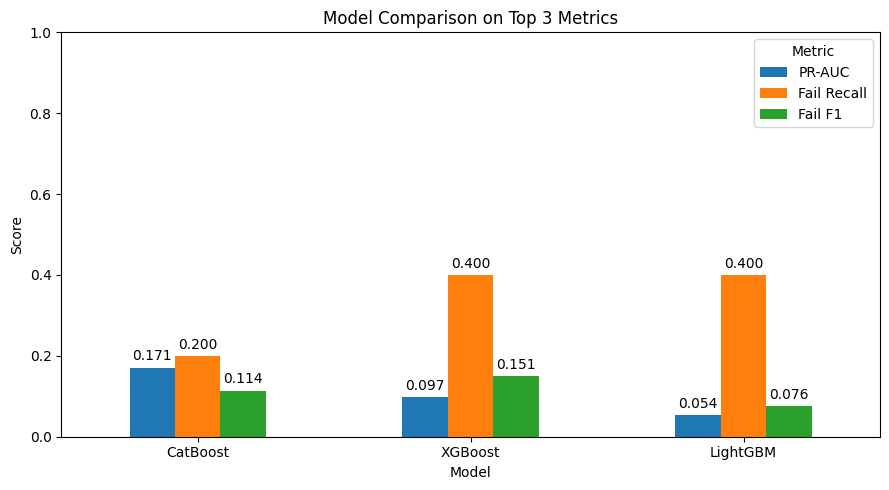

In [22]:
ax = results_df[["PR_AUC", "Fail_Recall", "Fail_F1"]].plot(
    kind="bar",
    figsize=(9, 5),
    rot=0
)

ax.set_title("Model Comparison on Top 3 Metrics")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(
    ["PR-AUC", "Fail Recall", "Fail F1"],
    title="Metric"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

In [23]:
selection_table = pd.DataFrame({
    "CV_PR_AUC": {
        model_name: studies[model_name].best_value
        for model_name in model_names
    },
    "Test_PR_AUC": results_df["PR_AUC"],
    "Test_Fail_Recall": results_df["Fail_Recall"],
    "Test_Fail_F1": results_df["Fail_F1"],
    "Test_Fail_F2": results_df["Fail_F2_aux"],
})

display(
    selection_table.sort_values(
        "CV_PR_AUC",
        ascending=False,
    ).round(4)
)

,CV_PR_AUC,Test_PR_AUC,Test_Fail_Recall,Test_Fail_F1,Test_Fail_F2
CatBoost,0.1565,0.1711,0.2,0.1143,0.1538
XGBoost,0.1437,0.0973,0.4,0.1509,0.2410
LightGBM,0.1083,0.0536,0.4,0.0762,0.1481


<br> <br> <br>

## Feature Importance

In [24]:
def get_top_n_xai_for_selected_failure(
    pipeline,
    X_train,
    X_test,
    y_test,
    selected_index,
    top_n=10,
    xai_method="shap",
    require_failure=True,
    random_state=None
):
    """
    Manually select one row from X_test using selected_index,
    apply either SHAP or LIME local feature importance,
    and return:

    1. xai_df:
        - feature_name
        - feature_importance

    2. selected_row_df:
        - the original selected row from X_test
        - true PassOrFail
        - predicted probability of Fail
        - selected XAI method
        - selected index

    Parameters
    ----------
    selected_index : index label from X_test
        The row index that should be explained.

    require_failure : bool, default=True
        If True, the selected row must have y_test == 1.
        If False, the function can explain any row.
    """

    xai_method = xai_method.lower()

    if xai_method not in ["shap", "lime"]:
        raise ValueError("xai_method must be either 'shap' or 'lime'.")

    # Ensure y_test is a pandas Series aligned with X_test
    if not isinstance(y_test, pd.Series):
        y_test = pd.Series(y_test, index=X_test.index)

    # 1. Validate manually selected row
    if selected_index not in X_test.index:
        raise ValueError(
            f"selected_index={selected_index} was not found in X_test.index."
        )

    if selected_index not in y_test.index:
        raise ValueError(
            f"selected_index={selected_index} was not found in y_test.index."
        )

    if require_failure and y_test.loc[selected_index] != 1:
        raise ValueError(
            f"selected_index={selected_index} is not a failure row. "
            f"y_test value is {y_test.loc[selected_index]}."
        )

    X_single = X_test.loc[[selected_index]]

    # 2. Extract preprocessing and model
    preprocessor = pipeline.named_steps["preprocess"]
    model = pipeline.named_steps["model"]

    # 3. Transform train and selected test row
    X_train_transformed = preprocessor.transform(X_train)
    X_single_transformed = preprocessor.transform(X_single)

    if hasattr(X_train_transformed, "toarray"):
        X_train_transformed = X_train_transformed.toarray()

    if hasattr(X_single_transformed, "toarray"):
        X_single_transformed = X_single_transformed.toarray()

    # 4. Get transformed feature names
    feature_names = preprocessor.get_feature_names_out()

    feature_names = [
        name.replace("num__", "").replace("cat__", "")
        for name in feature_names
    ]

    # 5. Predicted failure probability for selected row
    fail_probability = model.predict_proba(X_single_transformed)[0, 1]

    # 6. Store the selected original row
    selected_row_df = X_single.copy()
    selected_row_df["true_PassOrFail"] = int(y_test.loc[selected_index])
    selected_row_df["predicted_fail_probability"] = fail_probability
    selected_row_df["xai_method"] = xai_method
    selected_row_df["selected_index"] = selected_index

    # ============================================================
    # SHAP
    # ============================================================
    # if xai_method == "shap":
    #     import shap

    #     explainer = shap.TreeExplainer(model)
    #     shap_values = explainer.shap_values(X_single_transformed)

    #     if isinstance(shap_values, list):
    #         shap_values = shap_values[1]

    #     shap_values = np.array(shap_values)

    #     if len(shap_values.shape) == 3:
    #         shap_values = shap_values[:, :, 1]

    #     shap_values = shap_values.reshape(-1)

    #     xai_df = (
    #         pd.DataFrame({
    #             "feature_name": feature_names,
    #             "feature_importance": np.abs(shap_values)
    #         })
    #         .sort_values("feature_importance", ascending=False)
    #         .head(top_n)
    #         .reset_index(drop=True)
    #     )


    if xai_method == "shap":
        import shap

        explainer = shap.TreeExplainer(model)
        shap_output = explainer.shap_values(X_single_transformed)

        # Older SHAP versions may return one array per class.
        if isinstance(shap_output, list):
            shap_values = np.asarray(shap_output[1])

        # Newer SHAP versions may return a shap.Explanation object.
        elif hasattr(shap_output, "values"):
            shap_values = np.asarray(shap_output.values)

        else:
            shap_values = np.asarray(shap_output)

        # Possible binary-classification shape:
        # (n_samples, n_features, n_classes)
        if shap_values.ndim == 3:
            shap_values = shap_values[:, :, 1]

        shap_values = shap_values.reshape(-1)

        if len(shap_values) != len(feature_names):
            raise ValueError(
                "The number of SHAP values does not match the number "
                "of transformed features. "
                f"SHAP values: {len(shap_values)}, "
                f"features: {len(feature_names)}."
            )

        xai_df = pd.DataFrame({
            "feature_name": feature_names,

            # Preserve the signed model contribution.
            "feature_attribution": shap_values,

            # Use absolute magnitude only for ranking.
            "absolute_attribution": np.abs(shap_values),
        })

        xai_df["direction"] = np.select(
            [
                xai_df["feature_attribution"] > 0,
                xai_df["feature_attribution"] < 0,
            ],
            [
                "toward Fail",
                "toward Pass",
            ],
            default="neutral",
        )

        xai_df = (
            xai_df
            .sort_values(
                "absolute_attribution",
                ascending=False,
            )
            .head(top_n)
            .reset_index(drop=True)
        )



    # ============================================================
    # LIME
    # ============================================================
    # else:
    #     from lime.lime_tabular import LimeTabularExplainer

    #     explainer = LimeTabularExplainer(
    #         training_data=X_train_transformed,
    #         feature_names=feature_names,
    #         class_names=["Pass", "Fail"],
    #         mode="classification",
    #         discretize_continuous=True,
    #         random_state=random_state
    #     )

    #     explanation = explainer.explain_instance(
    #         data_row=X_single_transformed[0],
    #         predict_fn=model.predict_proba,
    #         num_features=top_n,
    #         labels=[1]
    #     )

    #     lime_map = explanation.as_map()[1]

    #     xai_df = (
    #         pd.DataFrame({
    #             "feature_name": [feature_names[i] for i, weight in lime_map],
    #             "feature_importance": [abs(weight) for i, weight in lime_map]
    #         })
    #         .sort_values("feature_importance", ascending=False)
    #         .head(top_n)
    #         .reset_index(drop=True)
    #     )

    else:
        from lime.lime_tabular import LimeTabularExplainer

        explainer = LimeTabularExplainer(
            training_data=X_train_transformed,
            feature_names=feature_names,
            class_names=["Pass", "Fail"],
            mode="classification",
            discretize_continuous=True,
            random_state=random_state,
        )

        explanation = explainer.explain_instance(
            data_row=X_single_transformed[0],
            predict_fn=model.predict_proba,
            num_features=top_n,
            labels=[1],
        )

        lime_map = explanation.as_map()[1]

        lime_feature_names = [
            feature_names[feature_index]
            for feature_index, weight in lime_map
        ]

        lime_weights = np.asarray([
            weight
            for feature_index, weight in lime_map
        ])

        xai_df = pd.DataFrame({
            "feature_name": lime_feature_names,

            # Preserve the signed local contribution.
            "feature_attribution": lime_weights,

            # Use magnitude only for ranking.
            "absolute_attribution": np.abs(lime_weights),
        })

        xai_df["direction"] = np.select(
            [
                xai_df["feature_attribution"] > 0,
                xai_df["feature_attribution"] < 0,
            ],
            [
                "toward Fail",
                "toward Pass",
            ],
            default="neutral",
        )

        xai_df = (
            xai_df
            .sort_values(
                "absolute_attribution",
                ascending=False,
            )
            .head(top_n)
            .reset_index(drop=True)
        )



    return xai_df, selected_row_df

In [25]:
X_test[y_test == 1]

,PART_NAME,EQUIP_CD,EQUIP_NAME,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
115,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,9.45,4.33,16.959999,59.580002,7.13,653.400024,0.0,68.839996,647.98999,60.700001,30.799999,292.500000,141.399994,136.800003,37.099998,59.099998,275.299988,275.299988,275.100006,269.799988,255.000000,230.100006,0.0,68.000000,25.000000,27.700001
116,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,9.45,4.33,16.959999,59.580002,7.13,653.400024,0.0,68.839996,647.98999,60.700001,30.799999,292.500000,141.399994,136.800003,37.099998,59.099998,275.299988,275.299988,275.100006,269.799988,255.000000,230.100006,0.0,68.000000,25.000000,27.700001
1347,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,1.06,0.93,12.920000,61.779999,6.80,654.260010,0.0,53.580002,4.63000,128.300003,30.700001,290.500000,142.500000,115.900002,55.599998,60.400002,286.200012,284.399994,285.299988,274.799988,265.399994,234.800003,0.0,66.800003,21.799999,23.000000
1415,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,1.06,0.93,12.900000,61.779999,6.80,654.260010,0.0,53.590000,4.63000,128.300003,30.799999,290.600006,142.399994,116.099998,56.200001,61.000000,286.600006,284.600006,285.000000,276.500000,264.899994,235.000000,0.0,66.800003,22.000000,23.100000
1515,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,1.06,0.94,12.990000,61.779999,6.81,654.260010,0.0,53.570000,4.63000,128.300003,30.799999,290.500000,142.699997,116.300003,56.000000,60.799999,286.299988,285.799988,285.000000,275.799988,264.899994,235.000000,0.0,66.199997,22.200001,23.400000
1621,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,1.06,0.94,12.900000,61.779999,6.81,654.250000,0.0,53.570000,4.63000,128.300003,30.799999,290.600006,142.600006,116.300003,55.900002,60.599998,285.100006,285.000000,284.700012,275.500000,264.799988,234.899994,0.0,66.000000,22.600000,23.600000
1937,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,1.06,0.94,12.960000,61.799999,6.81,654.229980,0.0,53.580002,4.63000,128.000000,30.799999,290.600006,142.800003,116.599998,56.500000,61.299999,285.299988,285.299988,284.700012,276.000000,264.700012,234.899994,0.0,64.500000,21.400000,22.700001
2021,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,1.06,0.94,12.890000,61.759998,6.80,654.239990,0.0,53.590000,4.63000,128.100006,30.799999,290.700012,142.800003,116.599998,56.200001,60.900002,286.299988,285.000000,285.399994,274.799988,265.000000,235.100006,0.0,64.000000,22.000000,23.299999
2105,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,1.06,0.94,12.930000,61.779999,6.80,654.250000,0.0,53.590000,4.63000,128.199997,30.900000,290.600006,142.699997,116.300003,55.799999,60.500000,285.299988,285.299988,284.899994,274.700012,265.299988,235.100006,0.0,64.900002,23.299999,24.700001
2163,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,1.06,0.94,12.890000,61.779999,6.79,654.239990,0.0,53.590000,4.63000,128.100006,30.900000,290.500000,142.800003,116.699997,56.299999,61.299999,286.000000,285.600006,285.000000,275.399994,264.899994,235.000000,0.0,65.099998,23.400000,24.900000


In [26]:
prediction_table

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,predicted_PassOrFail,failure_score,error_type
8,5f8929999c0189cc666ef87d,2020-10-16 05:01:46,2020-10-16 00:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,0,NaN,9.58,4.46,16.92,59.560001,7.13,653.409973,0.0,68.849998,647.98999,55.500000,30.600000,292.399994,141.800003,136.699997,37.400002,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,0.0,67.000000,25.000000,27.600000,0,0.442511,correct
12,5f8929ec9c0189cc666efbb9,2020-10-16 05:03:44,2020-10-16 00:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,0,NaN,9.56,4.45,16.90,59.520000,7.14,653.409973,0.0,68.839996,647.98999,55.700001,30.700001,292.500000,141.600006,136.300003,36.900002,59.000000,276.200012,275.200012,274.500000,270.299988,255.000000,230.100006,0.0,67.000000,25.000000,27.600000,0,0.356885,correct
17,5f892a9b9c0189cc666eff35,2020-10-16 05:06:43,2020-10-16 00:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,0,NaN,9.58,4.47,16.92,59.520000,7.13,653.409973,0.0,68.839996,647.98999,55.500000,30.700001,292.399994,141.699997,136.800003,37.099998,59.099998,276.399994,275.000000,275.799988,269.100006,254.399994,229.800003,0.0,67.800003,24.700001,27.600000,0,0.371443,correct
23,5f892b439c0189cc666f06d3,2020-10-16 05:09:41,2020-10-16 00:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,0,NaN,9.59,4.47,16.91,59.560001,7.13,653.409973,0.0,68.860001,647.98999,55.400002,30.600000,292.500000,141.800003,136.800003,37.700001,59.400002,276.100006,274.799988,274.500000,271.600006,254.500000,229.600006,0.0,67.099998,24.900000,27.500000,0,0.475036,correct
26,5f892b839c0189cc666f0a1a,2020-10-16 05:10:42,2020-10-16 00:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,0,NaN,9.59,4.47,16.90,59.580002,7.13,653.409973,0.0,68.830002,647.98999,55.400002,30.600000,292.500000,141.699997,136.800003,37.500000,59.299999,276.200012,275.000000,275.399994,271.799988,255.000000,230.100006,0.0,67.500000,24.900000,27.500000,0,0.326243,correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5188,5fa23c109c0189cc66e420d8,2020-11-04 05:27:02,2020-11-04 00:00:00,9,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,0,NaN,1.07,0.95,13.15,61.740002,6.79,654.219971,0.0,53.619999,4.63000,127.099998,30.900000,29.000000,143.399994,118.900002,57.700001,62.000000,286.000000,284.899994,284.799988,274.399994,265.799988,234.500000,0.0,63.400002,22.400000,24.200001,0,0.379475,correct
5199,5fa23d849c0189cc66e431b2,2020-11-04 05:34:13,2020-11-04 00:00:00,9,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,0,NaN,1.07,0.94,13.13,61.740002,6.79,654.239990,0.0,53.610001,4.63000,127.400002,31.000000,29.000000,143.100006,118.599998,57.500000,61.900002,286.000000,285.200012,285.600006,274.600006,264.899994,234.800003,0.0,64.000000,22.400000,24.400000,0,0.186377,correct
5202,5fa23e089c0189cc66e437a6,2020-11-04 05:35:16,2020-11-04 00:00:00,9,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,0,NaN,1.07,0.95,13.14,61.779999,6.79,654.229980,0.0,53.619999,4.63000,127.300003,31.000000,29.000000,143.199997,118.599998,57.500000,61.900002,285.299988,284.799988,284.700012,274.600006,265.100006,234.699997,0.0,63.099998,22.500000,24.400000,0,0.390602,correct
5218,5fa23fbd9c0189cc66e44de3,2020-11-04 05:43:29,2020-11-04 00:00:00,9,"RG3 MOLD'G W/SHLD, LH",S14,650톤-우진2호기,0,NaN,1.07,0.94,13.12,61.779999,6.79,654.250000,0.0,53.610001,4.63000,127.500000,31.100000,29.000000,143.000000

In [27]:
# Verify that rows selected by X_test[y_test == 1] are truly labeled as failures in prediction_table

failure_idx = X_test.index[y_test == 1]
missing_in_prediction_table = failure_idx.difference(prediction_table.index)

if len(missing_in_prediction_table) > 0:
    print(f"Missing {len(missing_in_prediction_table)} failure indices in prediction_table:")
    display(missing_in_prediction_table)
else:
    check_df = prediction_table.loc[failure_idx, [TARGET, "Reason", "predicted_PassOrFail","failure_score", "error_type"]].copy()
    check_df["y_test"] = y_test.loc[failure_idx].values
    check_df["target_is_failure"] = check_df[TARGET] == 1
    check_df["y_test_matches_target"] = check_df["y_test"] == check_df[TARGET]

    print(f"Total failure rows from y_test: {len(failure_idx)}")
    print(f"Rows with prediction_table[{TARGET}] == 1: {int(check_df['target_is_failure'].sum())}")
    print(f"Rows where y_test matches prediction_table[{TARGET}]: {int(check_df['y_test_matches_target'].sum())}")

    if check_df["target_is_failure"].all() and check_df["y_test_matches_target"].all():
        print("✅ All X_test[y_test == 1] rows are actual failures in prediction_table.")
    else:
        print("⚠️ Found mismatches. See rows below:")
        display(check_df[~(check_df["target_is_failure"] & check_df["y_test_matches_target"])])

    display(check_df.head(20))

Total failure rows from y_test: 10
Rows with prediction_table[PassOrFail] == 1: 10
Rows where y_test matches prediction_table[PassOrFail]: 10
✅ All X_test[y_test == 1] rows are actual failures in prediction_table.


,PassOrFail,Reason,predicted_PassOrFail,failure_score,error_type,y_test,target_is_failure,y_test_matches_target
115,1,미성형,1,0.785623,correct,1,True,True
116,1,미성형,1,0.848683,correct,1,True,True
1347,1,가스,0,0.099860,false_negative,1,True,True
1415,1,가스,0,0.128679,false_negative,1,True,True
1515,1,미성형,0,0.365255,false_negative,1,True,True
1621,1,가스,0,0.202479,false_negative,1,True,True
1937,1,가스,0,0.151646,false_negative,1,True,True
2021,1,미성형,0,0.151619,false_negative,1,True,True
2105,1,가스,0,0.465521,false_negative,1,True,True
2163,1,미성형,0,0.222923,false_negative,1,True,True


In [28]:
# Explanation candidates: TRUE POSITIVES only — actual failures that the
# selected model also predicted as failures. False negatives are excluded
# because explaining a failure the model did not detect would not reflect
# what the model actually learned.

true_positive_df = prediction_table[
    (prediction_table[TARGET] == 1)
    & (prediction_table["predicted_PassOrFail"] == 1)
]

print(f"True-positive failures available for explanation: {len(true_positive_df)}")
print("\nTrue positives by Reason:")
display(true_positive_df["Reason"].value_counts().to_frame("count"))

true_positive_df[["TimeStamp", TARGET, "Reason", "predicted_PassOrFail", "failure_score", "error_type"]]


True-positive failures available for explanation: 2

True positives by Reason:


,count
Reason,
미성형,2


,TimeStamp,PassOrFail,Reason,predicted_PassOrFail,failure_score,error_type
115,2020-10-16 05:55:21,1,미성형,1,0.785623,correct
116,2020-10-16 05:55:21,1,미성형,1,0.848683,correct


## Note


- 가스 => Gas <br> 미성형 => Unshaped <br>

- Initial allowable or startup defects (`초기허용불량`) correspond to the initial production samples, where defects are anticipated during process stabilization; they are **removed from the dataset entirely** in the split cell and are never trained on, tested on, or explained.

- Only **true positives** (actual failures that the model also predicted as failures) are candidates for the XAI and LLM-explanation stages, because a feature-importance explanation is only meaningful when the model actually detected the failure.


In [29]:
true_positive_df["Reason"]


115    미성형
116    미성형
Name: Reason, dtype: str

In [38]:
check_df

,PassOrFail,Reason,predicted_PassOrFail,failure_score,error_type,y_test,target_is_failure,y_test_matches_target
115,1,미성형,1,0.785623,correct,1,True,True
116,1,미성형,1,0.848683,correct,1,True,True
1347,1,가스,0,0.099860,false_negative,1,True,True
1415,1,가스,0,0.128679,false_negative,1,True,True
1515,1,미성형,0,0.365255,false_negative,1,True,True
1621,1,가스,0,0.202479,false_negative,1,True,True
1937,1,가스,0,0.151646,false_negative,1,True,True
2021,1,미성형,0,0.151619,false_negative,1,True,True
2105,1,가스,0,0.465521,false_negative,1,True,True
2163,1,미성형,0,0.222923,false_negative,1,True,True


In [107]:
# 9

In [ ]:
# # Pick one true-positive row (by position within true_positive_df) to explain.
row_number = 9


# --------------------------------------------------------------------------
# ------------------------ Only True Positives -----------------------------
# --------------------------------------------------------------------------

# row_reason = true_positive_df["Reason"].iloc[row_number]
# mapping = {"가스": "가스 => Gas", "미성형": "미성형 => Unshaped"}
# row_reason_md = mapping.get(row_reason, row_reason)

# # Candidate rows are true positives only, so the selected example is a
# # failure that the model also predicted as a failure.
# failed_x_test_rows = X_test.loc[true_positive_df.index]
# index = int(failed_x_test_rows.iloc[row_number].to_frame().T.index[0])

# top_n_shap_df, selected_failure_row_df = get_top_n_xai_for_selected_failure(
#     pipeline=best_model,
#     X_train=X_train,
#     X_test=X_test,
#     y_test=y_test,
#     selected_index=index,
#     top_n=10,
#     xai_method="shap",
#     require_failure=True,
#     # random_state=42
# )

# display(top_n_shap_df)
# display(failed_x_test_rows.iloc[row_number].to_frame().T)

# # This is the equivalent row from df. The indices differ because model_df was
# # re-indexed after removing the startup-defect rows.
# display(df.loc[df["_id"] == test_df.loc[index, "_id"], "Reason"])


# -------------------------------------------------------------------
# ------------------------ All the rows -----------------------------
# -------------------------------------------------------------------
row_reason = test_df[test_df["Reason"].notna()]["Reason"].iloc[row_number]
mapping = {"가스": "가스 => Gas", "미성형": "미성형 => Unshaped"}
row_reason_md = mapping.get(row_reason, row_reason)


failed_x_test_rows = X_test.loc[test_df.loc[test_df["Reason"].notna()].index]
index = int(failed_x_test_rows.iloc[row_number].to_frame().T.index[0])


top_n_shap_df, selected_failure_row_df = get_top_n_xai_for_selected_failure(
    pipeline=best_model,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    selected_index=index,
    top_n=10,
    xai_method="shap",
    require_failure=True,
    # random_state=42
)


display(top_n_shap_df)
display(failed_x_test_rows.iloc[row_number].to_frame().T)


cols = [] # all rows
cols = ["Reason"]

# This is the equivalent row from df. They have different index since the data is diplaced a little bit 
# based on the fact that we took several rows from X_test for df["Reasons"]
display(df.loc[df["_id"] == test_df.loc[index, "_id"], "Reason"])



,feature_name,feature_attribution,absolute_attribution,direction
0,"PART_NAME_RG3 MOLD'G W/SHLD, RH",0.553779,0.553779,toward Fail
1,Barrel_Temperature_1,0.539913,0.539913,toward Fail
2,Hopper_Temperature,0.271211,0.271211,toward Fail
3,Clamp_Close_Time,-0.164106,0.164106,toward Pass
4,Max_Screw_RPM,0.164078,0.164078,toward Fail
5,"PART_NAME_RG3 MOLD'G W/SHLD, LH",0.148409,0.148409,toward Fail
6,Injection_Time,0.136161,0.136161,toward Fail
7,Barrel_Temperature_2,0.118590,0.118590,toward Fail
8,Max_Injection_Speed,0.101720,0.101720,toward Fail
9,Filling_Time,0.100814,0.100814,toward Fail


,PART_NAME,EQUIP_CD,EQUIP_NAME,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
2163,"RG3 MOLD'G W/SHLD, RH",S14,650톤-우진2호기,1.06,0.94,12.89,61.779999,6.79,654.23999,0.0,53.59,4.63,128.100006,30.9,290.5,142.800003,116.699997,56.299999,61.299999,286.0,285.600006,285.0,275.399994,264.899994,235.0,0.0,65.099998,23.4,24.9


2163    미성형
Name: Reason, dtype: str

In [109]:
# Read the top_n_shap_df and append it as a markdown table to the explanation results file

# The kernel cwd may be either the notebooks/ folder or the project root,
# so pick whichever candidate directory actually exists (same pattern as DATA_PATH_CANDIDATES).
LLM_EXPLANATION_DIR = next(
    (p for p in [Path("../llm_explanation"), Path("llm_explanation")] if p.is_dir()),
    None,
)
if LLM_EXPLANATION_DIR is None:
    raise FileNotFoundError(
        "Could not find the llm_explanation directory. "
        f"Kernel cwd is {Path.cwd()} - update the candidate list."
    )

file_path = LLM_EXPLANATION_DIR / "explanation_results_sikdd.md"

table_markdown = top_n_shap_df.to_markdown(index=False)

# Create a section header and append the table
markdown_content = (
    f"\n\n## Top 10 SHAP Features for Index Row {int(index)}\n\n"
    f"{table_markdown}\n\n"
)

with open(file_path, "a", encoding="utf-8") as f:
    f.write(markdown_content)

print(f"Successfully appended top_n_shap_df table for Index Row {int(index)} to {file_path}")

Successfully appended top_n_shap_df table for Index Row 2163 to ..\llm_explanation\explanation_results_sikdd.md


<br> <br> <br>

## Generate an Expalnation Using LLM


In [110]:
feature_description_dict = {
    "PART_NAME": "The name or type of product part being manufactured.",
    "EQUIP_CD": "The machine or equipment code used to identify the production equipment.",
    "EQUIP_NAME": "The name of the machine or equipment used during production.",
    "Injection_Time": "The time taken to inject molten plastic into the mold.",
    "Filling_Time": "The time required to fill the mold cavity with material.",
    "Plasticizing_Time": "The time needed to melt and prepare plastic material before injection.",
    "Cycle_Time": "The total time required to complete one production cycle.",
    "Clamp_Close_Time": "The time taken for the mold clamp to close before injection starts.",
    "Cushion_Position": "The remaining screw position after injection, indicating leftover material in the barrel.",
    "Switch_Over_Position": "The screw position where the machine changes from injection control to pressure holding.",
    "Plasticizing_Position": "The screw position reached while preparing molten plastic for the next cycle.",
    "Clamp_Open_Position": "The mold opening position after the part has been formed.",
    "Max_Injection_Speed": "The highest speed reached while injecting material into the mold.",
    "Max_Screw_RPM": "The maximum rotation speed of the screw during plasticizing.",
    "Average_Screw_RPM": "The average screw rotation speed during material preparation.",
    "Max_Injection_Pressure": "The highest pressure applied while injecting material into the mold.",
    "Max_Switch_Over_Pressure": "The pressure at the moment the machine switches from injection to holding pressure.",
    "Max_Back_Pressure": "The highest resistance pressure applied during screw recovery and plasticizing.",
    "Average_Back_Pressure": "The average resistance pressure during material preparation.",
    "Barrel_Temperature_1": "The temperature in the first heating zone of the injection barrel.",
    "Barrel_Temperature_2": "The temperature in the second heating zone of the injection barrel.",
    "Barrel_Temperature_3": "The temperature in the third heating zone of the injection barrel.",
    "Barrel_Temperature_4": "The temperature in the fourth heating zone of the injection barrel.",
    "Barrel_Temperature_5": "The temperature in the fifth heating zone of the injection barrel.",
    "Barrel_Temperature_6": "The temperature in the sixth heating zone of the injection barrel.",
    "Barrel_Temperature_7": "The temperature in the seventh heating zone of the injection barrel.",
    "Hopper_Temperature": "The temperature around the hopper where raw plastic material enters the machine.",
    "Mold_Temperature_3": "The temperature measured in one monitored zone of the mold.",
    "Mold_Temperature_4": "The temperature measured in another monitored zone of the mold."
}

In [111]:
top_n_shap_df

,feature_name,feature_attribution,absolute_attribution,direction
0,"PART_NAME_RG3 MOLD'G W/SHLD, RH",0.553779,0.553779,toward Fail
1,Barrel_Temperature_1,0.539913,0.539913,toward Fail
2,Hopper_Temperature,0.271211,0.271211,toward Fail
3,Clamp_Close_Time,-0.164106,0.164106,toward Pass
4,Max_Screw_RPM,0.164078,0.164078,toward Fail
5,"PART_NAME_RG3 MOLD'G W/SHLD, LH",0.148409,0.148409,toward Fail
6,Injection_Time,0.136161,0.136161,toward Fail
7,Barrel_Temperature_2,0.118590,0.118590,toward Fail
8,Max_Injection_Speed,0.101720,0.101720,toward Fail
9,Filling_Time,0.100814,0.100814,toward Fail


In [112]:
import json
import os

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI


def _extract_text_from_openrouter_response(response):
    """
    Extract final assistant text from an OpenRouter/OpenAI-compatible
    chat-completion response.
    """
    try:
        message = response.choices[0].message
        content = getattr(message, "content", None)

        if isinstance(content, str) and content.strip():
            return content.strip()

        if isinstance(content, list):
            text_parts = []

            for part in content:
                if isinstance(part, dict):
                    part_text = (
                        part.get("text")
                        or part.get("content")
                    )
                else:
                    part_text = getattr(part, "text", None)

                if part_text:
                    text_parts.append(str(part_text))

            final_text = "\n".join(text_parts).strip()

            if final_text:
                return final_text

    except Exception:
        pass

    try:
        raw_response = response.model_dump()
        content = raw_response["choices"][0]["message"].get(
            "content"
        )

        if isinstance(content, str) and content.strip():
            return content.strip()

        if isinstance(content, list):
            text_parts = []

            for part in content:
                if not isinstance(part, dict):
                    continue

                part_text = (
                    part.get("text")
                    or part.get("content")
                )

                if part_text:
                    text_parts.append(str(part_text))

            final_text = "\n".join(text_parts).strip()

            if final_text:
                return final_text

    except Exception:
        pass

    return None


def _resolve_feature_description(
    feature_name,
    feature_description_dict,
):
    """
    Resolve an exact feature description or a description for a
    one-hot-encoded feature.

    Example:
        PART_NAME_RG3 MOLD'G W/SHLD
    can inherit the description stored under:
        PART_NAME
    """
    if feature_name in feature_description_dict:
        return feature_description_dict[feature_name]

    # Check longer dictionary keys first to prevent a short prefix
    # from matching too early.
    sorted_feature_keys = sorted(
        feature_description_dict.keys(),
        key=len,
        reverse=True,
    )

    for base_feature in sorted_feature_keys:
        prefix = f"{base_feature}_"

        if feature_name.startswith(prefix):
            category_value = feature_name[len(prefix):]

            return (
                f"{feature_description_dict[base_feature]} "
                f"The encoded category for this cycle is "
                f"'{category_value}'."
            )

    # Human-readable fallback when no description is available.
    return feature_name.replace("_", " ")


def _prepare_attribution_rows(
    top_n_shap_df,
    feature_description_dict,
    max_rows,
):
    """
    Validate and normalize the signed local-attribution table.
    """
    if top_n_shap_df is None or top_n_shap_df.empty:
        raise ValueError(
            "top_n_shap_df is empty. No local attribution rows "
            "were provided."
        )

    required_columns = {
        "feature_name",
        "feature_attribution",
    }

    missing_columns = (
        required_columns
        - set(top_n_shap_df.columns)
    )

    if missing_columns:
        raise ValueError(
            "top_n_shap_df is missing the required columns: "
            f"{sorted(missing_columns)}. "
            "The function expects signed local attributions."
        )

    attribution_rows = top_n_shap_df.copy()

    attribution_rows["feature_attribution"] = pd.to_numeric(
        attribution_rows["feature_attribution"],
        errors="coerce",
    )

    if attribution_rows["feature_attribution"].isna().any():
        invalid_features = attribution_rows.loc[
            attribution_rows["feature_attribution"].isna(),
            "feature_name",
        ].tolist()

        raise ValueError(
            "Some feature_attribution values are not numeric. "
            f"Affected features: {invalid_features}"
        )

    # Recalculate this from the signed values rather than trusting
    # a potentially stale column.
    attribution_rows["absolute_attribution"] = np.abs(
        attribution_rows["feature_attribution"]
    )

    # Recalculate direction so that it is always consistent with
    # feature_attribution.
    attribution_rows["direction"] = np.select(
        [
            attribution_rows["feature_attribution"] > 0,
            attribution_rows["feature_attribution"] < 0,
        ],
        [
            "toward Fail",
            "toward Pass",
        ],
        default="neutral",
    )

    attribution_rows = (
        attribution_rows
        .sort_values(
            "absolute_attribution",
            ascending=False,
        )
        .head(max_rows)
        .reset_index(drop=True)
    )

    attribution_rows["rank"] = (
        np.arange(len(attribution_rows)) + 1
    )

    attribution_rows["feature_description"] = (
        attribution_rows["feature_name"].apply(
            lambda feature_name: _resolve_feature_description(
                feature_name=feature_name,
                feature_description_dict=(
                    feature_description_dict
                ),
            )
        )
    )

    return attribution_rows


def generate_failure_explanation_with_llm(
    feature_description_dict,
    top_n_shap_df,
    llm_model="openai/gpt-5.4-mini",
    target_name="PassOrFail",
    max_rows=10,
    max_tokens=3000,
    reasoning_effort="low",
    return_prompt_only=False,
    debug=False,
):
    """
    Generate a short, user-facing explanation from signed local
    feature attributions.

    Expected top_n_shap_df columns
    --------------------------------
    feature_name
    feature_attribution
    absolute_attribution  # optional; recalculated internally
    direction             # optional; recalculated internally

    Interpretation
    --------------
    Positive attribution:
        pushes the model output toward Fail.

    Negative attribution:
        pushes the model output toward Pass.

    Absolute attribution:
        used only to rank the strength of local influence.

    The attributions explain model behavior and are not evidence of
    physical causality.
    """
    load_dotenv()

    api_key = os.getenv("OPENROUTER_API_KEY")

    if not api_key and not return_prompt_only:
        raise ValueError(
            "OPENROUTER_API_KEY was not found in the "
            "environment or .env file."
        )

    attribution_rows = _prepare_attribution_rows(
        top_n_shap_df=top_n_shap_df,
        feature_description_dict=feature_description_dict,
        max_rows=max_rows,
    )

    attribution_records = attribution_rows[
        [
            "rank",
            "feature_name",
            "feature_description",
            "feature_attribution",
            "absolute_attribution",
            "direction",
        ]
    ].to_dict(orient="records")

    system_prompt = """
You translate local model-attribution evidence into a concise explanation for
manufacturing and quality-control users.

The evidence describes how individual variables influenced the model's
assessment of failure risk for one production cycle.

Interpretation rules:
- A positive attribution pushed the model output toward Fail.
- A negative attribution pushed the model output toward Pass.
- Absolute attribution indicates influence magnitude and is used only for
  ranking.
- These values explain the model's behavior. They do not prove that a process
  variable physically caused the defect.
- The evidence does not contain sufficient information to conclude that a
  measurement was objectively too high, too low, abnormal, or outside an
  acceptable process range.

Writing rules:
- Write no more than five sentences.
- Use clear manufacturing language.
- Prefer the feature descriptions over raw encoded feature names.
- Prioritize the strongest five variables instead of mechanically
  listing every variable.
- Clearly distinguish variables pushing toward Fail from variables pushing
  toward Pass.
- Describe positive evidence as increasing the model's failure-risk
  assessment, not as causing the actual defect.
- Describe negative evidence as counteracting or reducing the model's
  failure-risk assessment.
- Do not make recommendations for changing settings unless intervention
  evidence or valid operating ranges are supplied.
- Do not mention SHAP, LIME, coefficients, attribution values, machine
  learning, or numerical scores in the final end-user explanation.
- Return only the explanation text, without a title, label, preamble, bullet
  list, or reasoning.
""".strip()

    user_prompt = f"""
Target:
{target_name}

Local evidence, ordered from strongest to weakest influence:
{json.dumps(attribution_records, indent=2, ensure_ascii=False)}

Explain how these process conditions shaped the failure-risk assessment for
this production cycle. Emphasize the strongest evidence pushing toward Fail,
while also acknowledging important evidence pushing toward Pass. Do not claim
that the evidence establishes the physical root cause of the recorded defect.
""".strip()

    messages = [
        {
            "role": "system",
            "content": system_prompt,
        },
        {
            "role": "user",
            "content": user_prompt,
        },
    ]

    # Avoid sending reasoning parameters to model families that may not
    # support OpenRouter's reasoning configuration.
    supports_reasoning = (
        llm_model.startswith("openai/gpt-5")
        or llm_model.startswith("openai/o")
    )

    extra_body = None

    if reasoning_effort is not None and supports_reasoning:
        extra_body = {
            "reasoning": {
                "effort": reasoning_effort,
                "exclude": True,
            }
        }

    prompt_payload = {
        "model": llm_model,
        "messages": messages,
        "system_prompt": system_prompt,
        "user_prompt": user_prompt,
        "attribution_records": attribution_records,
        "extra_body": extra_body,
        "max_tokens": max_tokens,
    }

    if return_prompt_only:
        return None, prompt_payload

    client = OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=api_key,
    )

    create_kwargs = {
        "model": llm_model,
        "messages": messages,
        "max_tokens": max_tokens,
    }

    if extra_body is not None:
        create_kwargs["extra_body"] = extra_body

    response = client.chat.completions.create(
        **create_kwargs
    )

    if debug:
        print(response.model_dump_json(indent=2))

    explanation = _extract_text_from_openrouter_response(
        response
    )

    if explanation is None:
        prompt_payload["raw_response"] = (
            response.model_dump()
        )

        raise ValueError(
            "The LLM response did not contain extractable final "
            "text. Increase max_tokens, reduce reasoning_effort, "
            "or run with debug=True to inspect the raw response."
        )

    return explanation, prompt_payload

In [113]:
from pathlib import Path

from IPython.display import Markdown, display


file_path = Path(
    "../llm_explanation/explanation_results_sikdd.md"
)

# Prevent FileNotFoundError when the directory is missing.
file_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

llm_models = [
    "openai/gpt-5.4-mini",
    "google/gemini-3.1-flash-lite",
    "mistralai/devstral-2512",
]

explanations = {}

for llm_model in llm_models:
    print("-" * 100)
    print(f"Generating explanation with {llm_model}")

    try:
        explanation, prompt_payload = (
            generate_failure_explanation_with_llm(
                feature_description_dict=(
                    feature_description_dict
                ),
                top_n_shap_df=top_n_shap_df,
                llm_model=llm_model,
                target_name="PassOrFail",
                max_rows=10,
                max_tokens=3000,
                reasoning_effort="low",
                debug=False,
            )
        )

    except Exception as error:
        explanations[llm_model] = None

        print(
            f"Explanation generation failed for "
            f"{llm_model}: {error}"
        )

        continue

    explanations[llm_model] = explanation

    markdown_content = (
        f"{'-' * 100}\n"
        f"**Model:** `{llm_model}`\n\n"
        f"**Index Row:** {int(index)}\n\n"
        f"**Reason:** {row_reason_md}\n\n"
        f"{explanation}\n\n"
    )

    with file_path.open(
        "a",
        encoding="utf-8",
    ) as output_file:
        output_file.write(markdown_content)

    print(
        f"Successfully appended results for index "
        f"{int(index)} to {file_path}"
    )

    display(
        Markdown(
            f"**Model:** `{llm_model}`"
        )
    )
    display(
        Markdown(
            f"**Index Row:** {int(index)}"
        )
    )
    display(
        Markdown(explanation)
    )

# Separate this production-cycle case from the next one.
with file_path.open(
    "a",
    encoding="utf-8",
) as output_file:
    output_file.write(
        f"{'-' * 100}\n"
        f"{'-' * 100}\n"
        f"{'-' * 100}\n"
    )

----------------------------------------------------------------------------------------------------
Generating explanation with openai/gpt-5.4-mini
Successfully appended results for index 2163 to ..\llm_explanation\explanation_results_sikdd.md


**Model:** `openai/gpt-5.4-mini`

**Index Row:** 2163

The model’s failure-risk assessment was driven mainly by the product type for this cycle and by process conditions around the barrel and hopper, with the RG3 MOLD'G W/SHLD, RH part category, the first barrel heating zone, and hopper temperature all pushing the assessment toward Fail. Additional process evidence also nudged the result toward Fail from the maximum screw speed, the left-hand part category, injection time, the second barrel heating zone, maximum injection speed, and filling time. One factor, clamp close time, pushed in the opposite direction and reduced the model’s failure-risk assessment. These signals describe how the model weighed the cycle, but they do not prove that any one condition physically caused the recorded defect or that any value was outside an acceptable range.

----------------------------------------------------------------------------------------------------
Generating explanation with google/gemini-3.1-flash-lite
Successfully appended results for index 2163 to ..\llm_explanation\explanation_results_sikdd.md


...

The production of the RG3 mold with shield (RH) most significantly increased the model’s assessment of failure risk for this cycle. Elevated temperature settings in the first heating zone of the injection barrel and the hopper, along with higher maximum screw rotation speeds, further contributed to this assessment. Conversely, the time taken for the mold clamp to close acted to reduce the model's failure-risk assessment. Please note that these factors reflect the model's behavior and do not confirm the physical cause of any production issues.

----------------------------------------------------------------------------------------------------
Generating explanation with mistralai/devstral-2512
Successfully appended results for index 2163 to ..\llm_explanation\explanation_results_sikdd.md


**Model:** `mistralai/devstral-2512`

**Index Row:** 2163

The model's failure-risk assessment for this cycle was most strongly influenced by the part type 'RG3 MOLD'G W/SHLD, RH' and high barrel temperature in the first heating zone, both increasing the risk of failure. Elevated hopper temperature and maximum screw RPM further contributed to the higher risk assessment, while the clamp close time acted to reduce the perceived risk. Other factors like injection time and barrel temperature in the second heating zone also played a smaller role in raising the failure risk. The evidence suggests these conditions collectively shaped the model's output, though it does not confirm they physically caused the defect. The part type 'RG3 MOLD'G W/SHLD, LH' had a lesser but still notable impact on increasing failure risk.

In [114]:
top_n_shap_df 

,feature_name,feature_attribution,absolute_attribution,direction
0,"PART_NAME_RG3 MOLD'G W/SHLD, RH",0.553779,0.553779,toward Fail
1,Barrel_Temperature_1,0.539913,0.539913,toward Fail
2,Hopper_Temperature,0.271211,0.271211,toward Fail
3,Clamp_Close_Time,-0.164106,0.164106,toward Pass
4,Max_Screw_RPM,0.164078,0.164078,toward Fail
5,"PART_NAME_RG3 MOLD'G W/SHLD, LH",0.148409,0.148409,toward Fail
6,Injection_Time,0.136161,0.136161,toward Fail
7,Barrel_Temperature_2,0.118590,0.118590,toward Fail
8,Max_Injection_Speed,0.101720,0.101720,toward Fail
9,Filling_Time,0.100814,0.100814,toward Fail
